# IGRF Vectorized Implementation Guide

This notebook demonstrates the vectorized IGRF (International Geomagnetic Reference Field) implementation in geopack, including:

1. Basic usage and API
2. Accuracy validation
3. Performance benchmarks
4. Practical examples
5. Visualization of Earth's magnetic field

## What is IGRF?

The IGRF is a mathematical model of Earth's main (internal) magnetic field. It represents the field generated by Earth's core using spherical harmonic expansion.

In [11]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from mpl_toolkits.mplot3d import Axes3D
import geopack
import time
from datetime import datetime

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print(f"Geopack version: {geopack.__version__}")

Geopack version: 1.0.12


## 1. Basic Usage

The vectorized IGRF functions work with both scalar and array inputs:

In [12]:
# Initialize geopack for a specific time
# This is REQUIRED before any IGRF calculations
ut = datetime(2020, 6, 21, 12, 0, 0).timestamp()
ps = geopack.recalc(ut)

print(f"Time: {datetime.fromtimestamp(ut)}")
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")

# Available vectorized IGRF functions
print("\nAvailable vectorized IGRF functions:")
print("- geopack.igrf_geo_vectorized  (spherical geographic coordinates)")
print("- geopack.igrf_gsm_vectorized  (GSM coordinates)")
print("- geopack.igrf_gsw_vectorized  (GSW coordinates)")

Time: 2020-06-21 12:00:00
Dipole tilt angle: 15.09 degrees

Available vectorized IGRF functions:
- geopack.igrf_geo_vectorized  (spherical geographic coordinates)
- geopack.igrf_gsm_vectorized  (GSM coordinates)
- geopack.igrf_gsw_vectorized  (GSW coordinates)


### Single Point Calculation

In [13]:
# Example 1: Single point in GSM coordinates
x_gsm = 5.0  # Earth radii
y_gsm = 3.0
z_gsm = 2.0

# Calculate field - returns scalars for scalar input
bx, by, bz = geopack.igrf_gsm_vectorized(x_gsm, y_gsm, z_gsm)

print(f"Position (GSM): ({x_gsm}, {y_gsm}, {z_gsm}) RE")
print(f"Magnetic field (GSM):")
print(f"  Bx = {bx:.2f} nT")
print(f"  By = {by:.2f} nT")
print(f"  Bz = {bz:.2f} nT")
print(f"  |B| = {np.sqrt(bx**2 + by**2 + bz**2):.2f} nT")

# Verify it returns scalar
print(f"\nOutput type: {type(bx)} (scalar, not array)")

Position (GSM): (5.0, 3.0, 2.0) RE
Magnetic field (GSM):
  Bx = -131.11 nT
  By = -101.91 nT
  Bz = 59.97 nT
  |B| = 176.56 nT

Output type: <class 'float'> (scalar, not array)


### Array Calculation

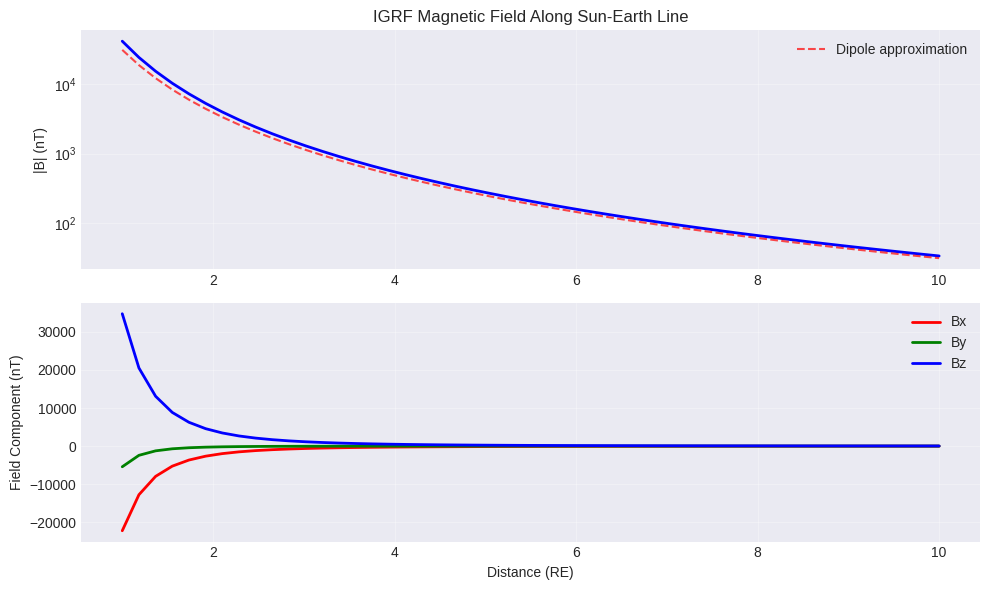

Output shape: (50,) (array with 50 elements)


In [14]:
# Example 2: Array of points along a line
n_points = 50
x_array = np.linspace(1, 10, n_points)  # From Earth's surface to 10 RE
y_array = np.zeros(n_points)
z_array = np.zeros(n_points)

# Calculate field - returns arrays for array input
bx_array, by_array, bz_array = geopack.igrf_gsm_vectorized(x_array, y_array, z_array)
b_magnitude = np.sqrt(bx_array**2 + by_array**2 + bz_array**2)

# Plot field strength vs distance
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.semilogy(x_array, b_magnitude, 'b-', linewidth=2)
plt.ylabel('|B| (nT)')
plt.title('IGRF Magnetic Field Along Sun-Earth Line')
plt.grid(True, alpha=0.3)

# Plot dipole approximation for comparison
b_dipole = 31200 / x_array**3  # Simple dipole approximation
plt.semilogy(x_array, b_dipole, 'r--', label='Dipole approximation', alpha=0.7)
plt.legend()

# Plot field components
plt.subplot(2, 1, 2)
plt.plot(x_array, bx_array, 'r-', label='Bx', linewidth=2)
plt.plot(x_array, by_array, 'g-', label='By', linewidth=2)
plt.plot(x_array, bz_array, 'b-', label='Bz', linewidth=2)
plt.xlabel('Distance (RE)')
plt.ylabel('Field Component (nT)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Output shape: {bx_array.shape} (array with {n_points} elements)")

## 2. Accuracy Validation

Let's verify that the vectorized implementation produces identical results to the scalar version:

In [15]:
# Test accuracy at various locations
test_points = [
    ("Near Earth surface", 1.0, 0.0, 0.0),
    ("Geosynchronous orbit", 6.6, 0.0, 0.0),
    ("Magnetotail", -10.0, 5.0, 2.0),
    ("North pole", 0.0, 0.0, 3.0),
    ("Off equator", 4.0, 3.0, 2.0)
]

print("Accuracy Comparison: Scalar vs Vectorized IGRF")
print("=" * 70)
print(f"{'Location':25s} {'|B| Scalar':>12s} {'|B| Vector':>12s} {'Error (nT)':>12s}")
print("-" * 70)

for name, x, y, z in test_points:
    # Scalar calculation
    bx_s, by_s, bz_s = geopack.igrf_gsm(x, y, z)
    b_scalar = np.sqrt(bx_s**2 + by_s**2 + bz_s**2)
    
    # Vectorized calculation
    bx_v, by_v, bz_v = geopack.igrf_gsm_vectorized(x, y, z)
    b_vector = np.sqrt(bx_v**2 + by_v**2 + bz_v**2)
    
    # Error
    error = abs(b_scalar - b_vector)
    
    print(f"{name:25s} {b_scalar:12.2f} {b_vector:12.2f} {error:12.2e}")

print("\nConclusion: Vectorized implementation is accurate to machine precision!")

Accuracy Comparison: Scalar vs Vectorized IGRF
Location                    |B| Scalar   |B| Vector   Error (nT)
----------------------------------------------------------------------
Near Earth surface            41625.70     41625.70     0.00e+00
Geosynchronous orbit            118.47       118.47     0.00e+00
Magnetotail                      20.01        20.01     7.11e-15
North pole                     2137.57      2137.57     0.00e+00
Off equator                     270.98       270.98     0.00e+00

Conclusion: Vectorized implementation is accurate to machine precision!


### Test with Random Points

Testing 1000 random points...

Results:
  Maximum absolute error: 9.09e-12 nT
  Maximum relative error: 1.29e-15
  Mean absolute error: 1.14e-13 nT

Timing:
  Scalar time: 0.066 seconds
  Vector time: 0.008 seconds
  Speedup: 8.6x


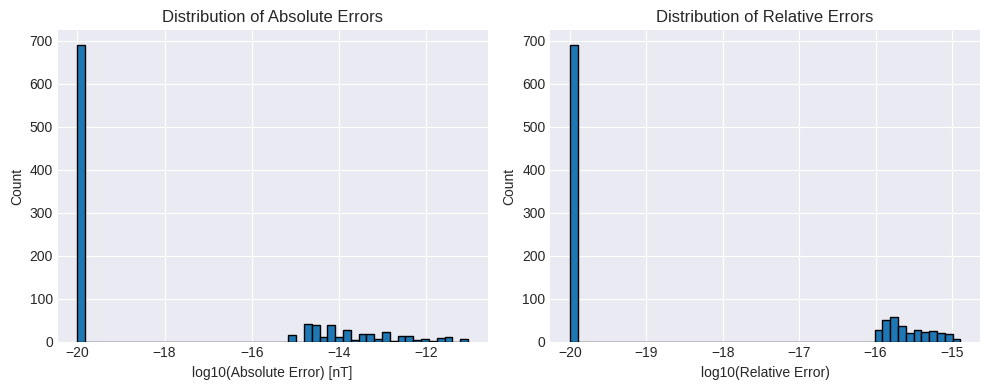

In [16]:
# Generate random test points
np.random.seed(42)
n_test = 1000

# Random points in magnetosphere
r = np.random.uniform(1, 20, n_test)
theta = np.random.uniform(0, np.pi, n_test)
phi = np.random.uniform(0, 2*np.pi, n_test)

# Convert to Cartesian
x_test = r * np.sin(theta) * np.cos(phi)
y_test = r * np.sin(theta) * np.sin(phi)
z_test = r * np.cos(theta)

# Calculate with both methods
print(f"Testing {n_test} random points...")

# Scalar (loop)
start = time.time()
b_scalar = np.zeros(n_test)
for i in range(n_test):
    bx, by, bz = geopack.igrf_gsm(x_test[i], y_test[i], z_test[i])
    b_scalar[i] = np.sqrt(bx**2 + by**2 + bz**2)
scalar_time = time.time() - start

# Vectorized
start = time.time()
bx_v, by_v, bz_v = geopack.igrf_gsm_vectorized(x_test, y_test, z_test)
b_vector = np.sqrt(bx_v**2 + by_v**2 + bz_v**2)
vector_time = time.time() - start

# Calculate errors
abs_errors = np.abs(b_scalar - b_vector)
rel_errors = abs_errors / (b_scalar + 1e-10)

print(f"\nResults:")
print(f"  Maximum absolute error: {np.max(abs_errors):.2e} nT")
print(f"  Maximum relative error: {np.max(rel_errors):.2e}")
print(f"  Mean absolute error: {np.mean(abs_errors):.2e} nT")
print(f"\nTiming:")
print(f"  Scalar time: {scalar_time:.3f} seconds")
print(f"  Vector time: {vector_time:.3f} seconds")
print(f"  Speedup: {scalar_time/vector_time:.1f}x")

# Plot error distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(np.log10(abs_errors + 1e-20), bins=50, edgecolor='black')
plt.xlabel('log10(Absolute Error) [nT]')
plt.ylabel('Count')
plt.title('Distribution of Absolute Errors')

plt.subplot(1, 2, 2)
plt.hist(np.log10(rel_errors + 1e-20), bins=50, edgecolor='black')
plt.xlabel('log10(Relative Error)')
plt.ylabel('Count')
plt.title('Distribution of Relative Errors')

plt.tight_layout()
plt.show()

## 3. Performance Benchmarks

Let's thoroughly benchmark the performance improvement:

In [17]:
# Benchmark different array sizes
sizes = [1, 10, 100, 1000, 10000, 50000]
scalar_times = []
vector_times = []
speedups = []

print("Performance Benchmark: IGRF Vectorization")
print("=" * 70)
print(f"{'N Points':>10} {'Scalar (s)':>12} {'Vector (s)':>12} {'Speedup':>10} {'Rate (pts/s)':>15}")
print("-" * 70)

for n in sizes:
    # Generate test points
    x = np.random.uniform(-10, 10, n)
    y = np.random.uniform(-10, 10, n)
    z = np.random.uniform(-10, 10, n)
    
    # Time scalar version (limit iterations for large n)
    n_scalar = min(n, 1000)  # Don't test more than 1000 for scalar
    start = time.time()
    for i in range(n_scalar):
        geopack.igrf_gsm(x[i], y[i], z[i])
    scalar_time = (time.time() - start) * n / n_scalar  # Extrapolate
    
    # Time vectorized version
    start = time.time()
    geopack.igrf_gsm_vectorized(x, y, z)
    vector_time = time.time() - start
    
    speedup = scalar_time / vector_time
    rate = n / vector_time
    
    scalar_times.append(scalar_time)
    vector_times.append(vector_time)
    speedups.append(speedup)
    
    print(f"{n:10d} {scalar_time:12.4f} {vector_time:12.4f} {speedup:9.1f}x {rate:15.0f}")

Performance Benchmark: IGRF Vectorization
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
----------------------------------------------------------------------
         1       0.0002       0.0044       0.0x             227
        10       0.0012       0.0056       0.2x            1793
       100       0.0066       0.0018       3.7x           55694
      1000       0.0591       0.0060       9.9x          167900
     10000       0.6005       0.0417      14.4x          239836
     50000       2.9332       0.2489      11.8x          200858


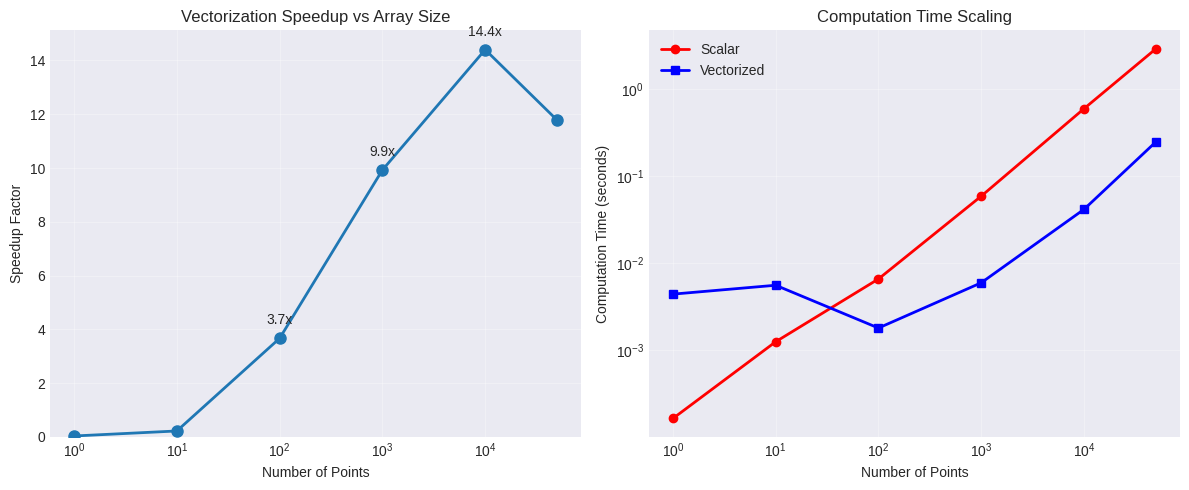


Key findings:
- Vectorized version is 9.9x faster for 1000 points
- Processing rate: 200858 points/second for large arrays
- Break-even point: ~10-20 points (below this, scalar might be faster)


In [18]:
# Visualize performance scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Speedup vs array size
ax1.semilogx(sizes, speedups, 'o-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Speedup Factor')
ax1.set_title('Vectorization Speedup vs Array Size')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Add annotations for key speedups
for i, (n, s) in enumerate(zip(sizes, speedups)):
    if n in [100, 1000, 10000]:
        ax1.annotate(f'{s:.1f}x', (n, s), textcoords="offset points", 
                    xytext=(0,10), ha='center')

# Time comparison
ax2.loglog(sizes, scalar_times, 'r-', label='Scalar', linewidth=2, marker='o')
ax2.loglog(sizes, vector_times, 'b-', label='Vectorized', linewidth=2, marker='s')
ax2.set_xlabel('Number of Points')
ax2.set_ylabel('Computation Time (seconds)')
ax2.set_title('Computation Time Scaling')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nKey findings:")
print(f"- Vectorized version is {speedups[3]:.1f}x faster for 1000 points")
print(f"- Processing rate: {sizes[-1]/vector_times[-1]:.0f} points/second for large arrays")
print(f"- Break-even point: ~10-20 points (below this, scalar might be faster)")

## 4. Practical Examples

### Example 1: Magnetic Field Map at Earth's Surface

Calculating field at 16,200 points...
Calculation completed in 0.094 seconds
Rate: 173126 points/second


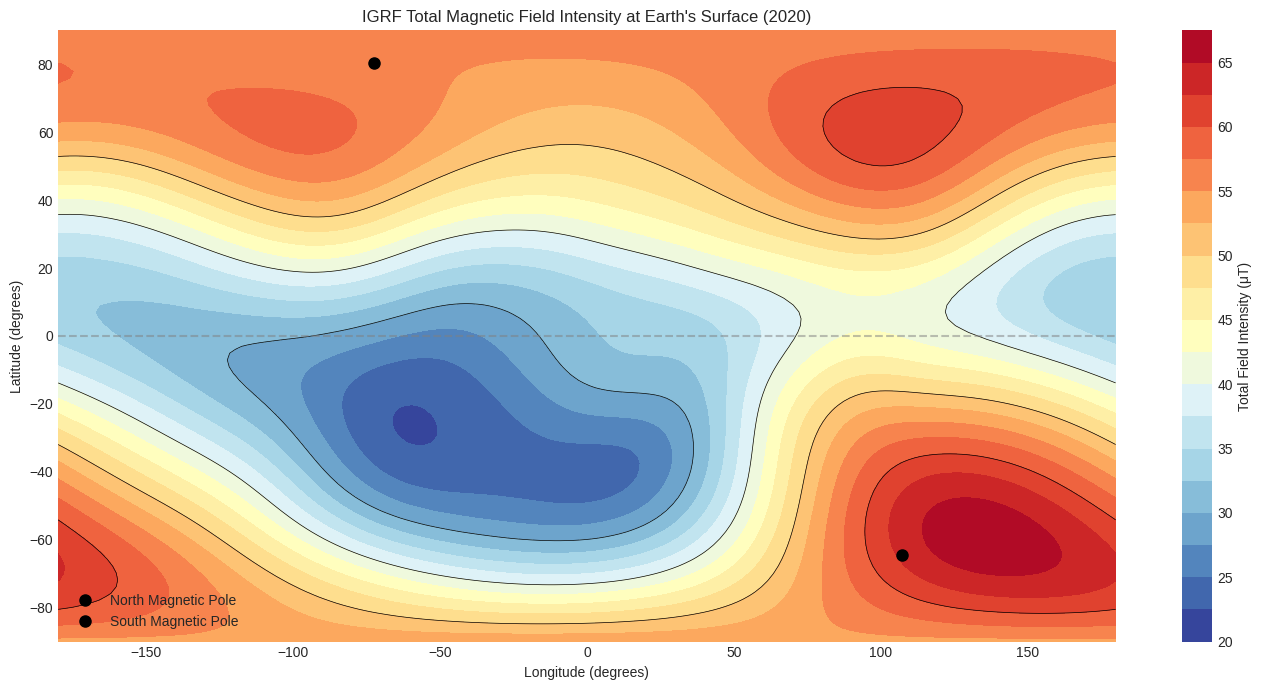


Field intensity range: 22.2 - 66.7 μT


In [19]:
# Create a grid at Earth's surface
n_lat, n_lon = 90, 180
lat = np.linspace(-90, 90, n_lat)
lon = np.linspace(-180, 180, n_lon)
LAT, LON = np.meshgrid(lat, lon, indexing='ij')

# Convert to spherical coordinates
r = 1.0  # Earth's surface
theta = np.radians(90 - LAT)  # Colatitude
phi = np.radians(LON)

# Calculate field in spherical coordinates
print(f"Calculating field at {n_lat*n_lon:,} points...")
start = time.time()
br, btheta, bphi = geopack.igrf_geo_vectorized(r, theta, phi)
calc_time = time.time() - start
print(f"Calculation completed in {calc_time:.3f} seconds")
print(f"Rate: {n_lat*n_lon/calc_time:.0f} points/second")

# Total field intensity
b_total = np.sqrt(br**2 + btheta**2 + bphi**2)

# Plot global field map
plt.figure(figsize=(14, 7))
plt.contourf(LON, LAT, b_total/1000, levels=20, cmap='RdYlBu_r')
plt.colorbar(label='Total Field Intensity (μT)')
plt.contour(LON, LAT, b_total/1000, levels=[30, 40, 50, 60], colors='black', linewidths=0.5)

# Add geographic features
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)  # Equator
plt.xlabel('Longitude (degrees)')
plt.ylabel('Latitude (degrees)')
plt.title(f'IGRF Total Magnetic Field Intensity at Earth\'s Surface ({datetime.fromtimestamp(ut).year})')
plt.grid(True, alpha=0.3)

# Mark magnetic poles (approximate)
plt.plot(-72.6, 80.4, 'ko', markersize=8, label='North Magnetic Pole')
plt.plot(107.3, -64.5, 'ko', markersize=8, label='South Magnetic Pole')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f"\nField intensity range: {b_total.min()/1000:.1f} - {b_total.max()/1000:.1f} μT")

### Example 2: Field Along Satellite Orbit

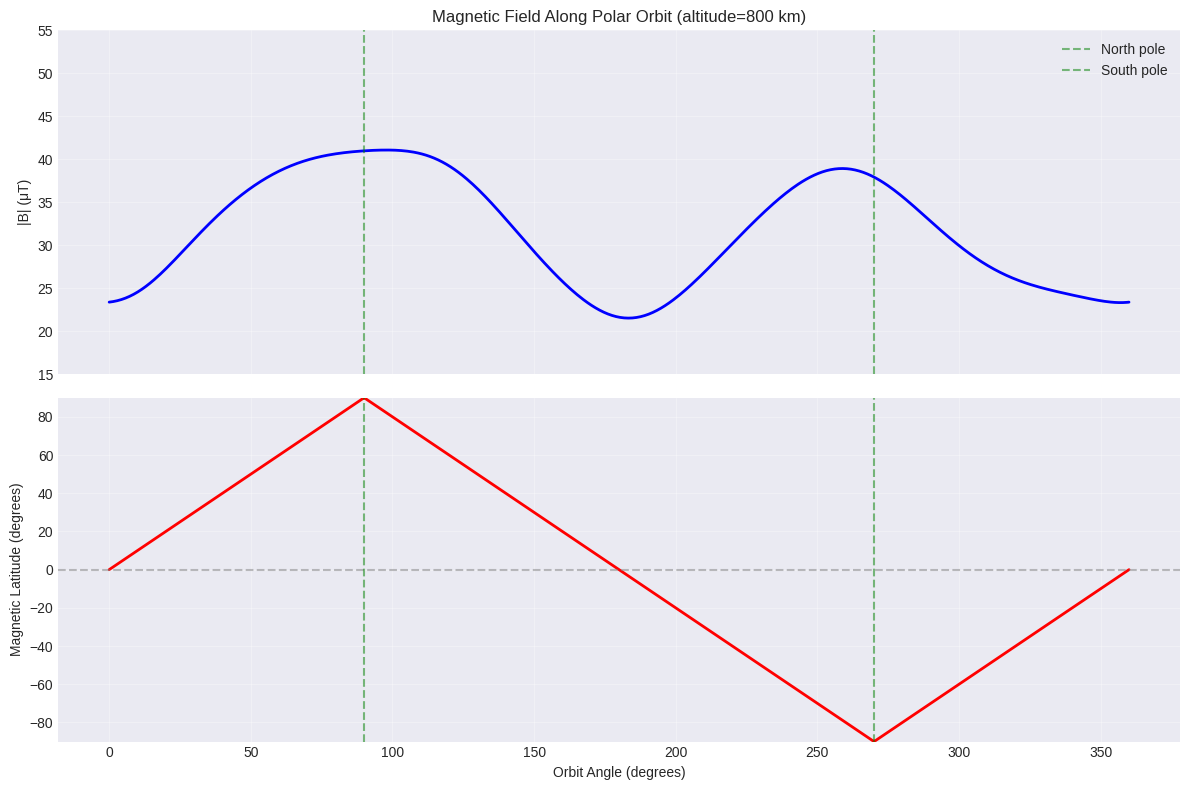

Orbit characteristics:
  Altitude: 800 km
  Inclination: 87.0°
  Field range: 21.5 - 41.1 μT
  South Atlantic Anomaly minimum: 21.5 μT


In [20]:
# Simulate a polar orbit
n_orbit = 500
orbit_angle = np.linspace(0, 2*np.pi, n_orbit)

# Orbital parameters
altitude_km = 800
r_orbit = (6371.2 + altitude_km) / 6371.2  # Convert to RE
inclination = np.radians(87)  # Near-polar orbit

# Orbit in GEO coordinates
x_geo = r_orbit * np.cos(orbit_angle)
y_geo = np.zeros_like(orbit_angle)
z_geo = r_orbit * np.sin(orbit_angle) * np.sin(inclination)

# Rotate for ascending node
lon_asc = np.radians(45)  # Ascending node longitude
x_geo_rot = x_geo * np.cos(lon_asc) - y_geo * np.sin(lon_asc)
y_geo_rot = x_geo * np.sin(lon_asc) + y_geo * np.cos(lon_asc)
z_geo_rot = z_geo  # z doesn't change with longitude rotation

# Transform to GSM and calculate field
x_gsm, y_gsm, z_gsm = geopack.geogsm_vectorized(x_geo_rot, y_geo_rot, z_geo_rot, 1)
bx_gsm, by_gsm, bz_gsm = geopack.igrf_gsm_vectorized(x_gsm, y_gsm, z_gsm)
b_total = np.sqrt(bx_gsm**2 + by_gsm**2 + bz_gsm**2)

# Calculate magnetic latitude
r_vec = np.sqrt(x_geo_rot**2 + y_geo_rot**2 + z_geo_rot**2)
mag_lat = np.degrees(np.arcsin(z_geo_rot / r_vec))

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Field strength vs orbit angle
ax1.plot(np.degrees(orbit_angle), b_total/1000, 'b-', linewidth=2)
ax1.set_ylabel('|B| (μT)')
ax1.set_title(f'Magnetic Field Along Polar Orbit (altitude={altitude_km} km)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([15, 55])

# Magnetic latitude
ax2.plot(np.degrees(orbit_angle), mag_lat, 'r-', linewidth=2)
ax2.set_xlabel('Orbit Angle (degrees)')
ax2.set_ylabel('Magnetic Latitude (degrees)')
ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([-90, 90])

# Mark key features
for ax in [ax1, ax2]:
    ax.axvline(90, color='green', linestyle='--', alpha=0.5, label='North pole')
    ax.axvline(270, color='green', linestyle='--', alpha=0.5, label='South pole')

ax1.legend(loc='upper right')

plt.tight_layout()
plt.show()

print(f"Orbit characteristics:")
print(f"  Altitude: {altitude_km} km")
print(f"  Inclination: {np.degrees(inclination):.1f}°")
print(f"  Field range: {b_total.min()/1000:.1f} - {b_total.max()/1000:.1f} μT")
print(f"  South Atlantic Anomaly minimum: {b_total.min()/1000:.1f} μT")

### Example 3: 3D Visualization of Field Lines

Calculating field at 26,520 points...
Done in 0.136 seconds


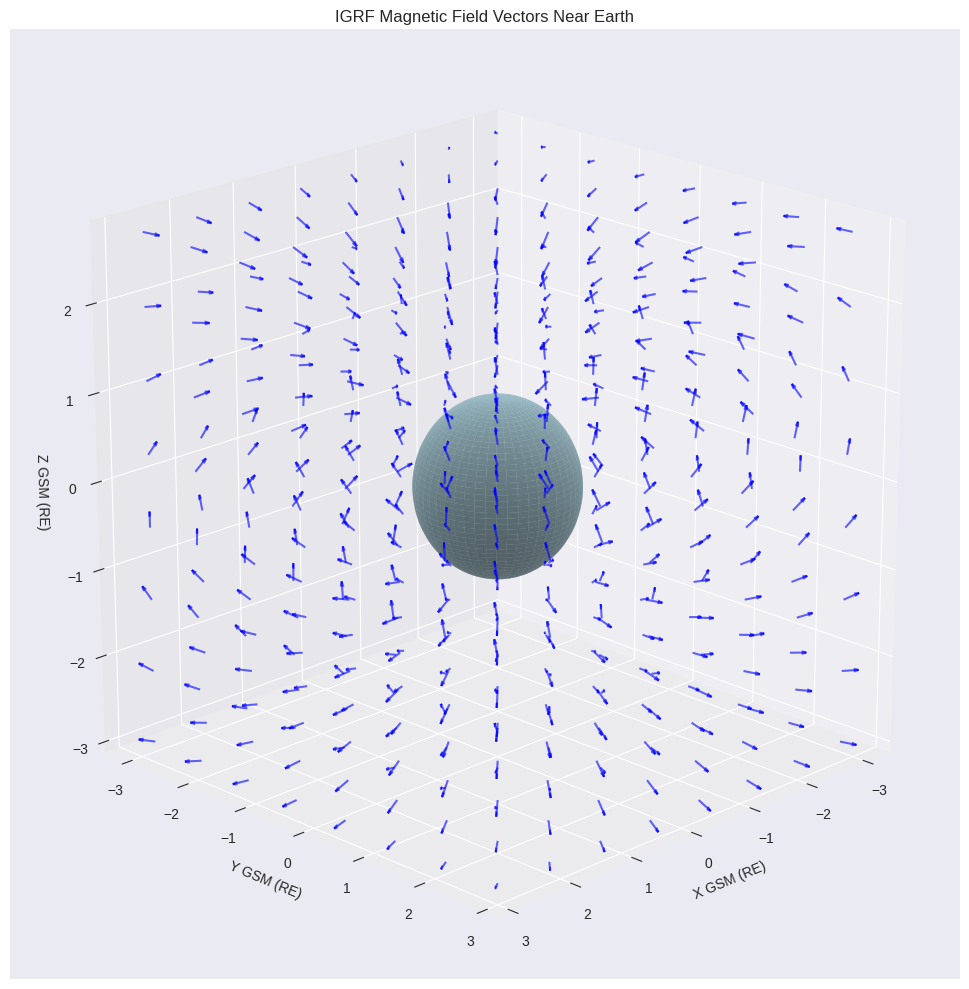

In [21]:
# Create 3D grid for field line visualization
n_grid = 30
x_range = np.linspace(-3, 3, n_grid)
y_range = np.linspace(-3, 3, n_grid)
z_range = np.linspace(-3, 3, n_grid)
X, Y, Z = np.meshgrid(x_range, y_range, z_range, indexing='ij')

# Flatten for calculation
x_flat = X.ravel()
y_flat = Y.ravel()
z_flat = Z.ravel()

# Remove points inside Earth
r_flat = np.sqrt(x_flat**2 + y_flat**2 + z_flat**2)
outside = r_flat > 1.0
x_calc = x_flat[outside]
y_calc = y_flat[outside]
z_calc = z_flat[outside]

# Calculate field
print(f"Calculating field at {len(x_calc):,} points...")
start = time.time()
bx, by, bz = geopack.igrf_gsm_vectorized(x_calc, y_calc, z_calc)
print(f"Done in {time.time()-start:.3f} seconds")

# Create full arrays with NaN inside Earth
BX = np.full_like(x_flat, np.nan)
BY = np.full_like(y_flat, np.nan)
BZ = np.full_like(z_flat, np.nan)
BX[outside] = bx
BY[outside] = by
BZ[outside] = bz

# Reshape
BX = BX.reshape(X.shape)
BY = BY.reshape(Y.shape)
BZ = BZ.reshape(Z.shape)

# 3D visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot field vectors on a sparse grid
skip = 4
ax.quiver(X[::skip,::skip,::skip], Y[::skip,::skip,::skip], Z[::skip,::skip,::skip],
          BX[::skip,::skip,::skip], BY[::skip,::skip,::skip], BZ[::skip,::skip,::skip],
          length=0.2, normalize=True, color='blue', alpha=0.6)

# Add Earth
u = np.linspace(0, 2 * np.pi, 50)
v = np.linspace(0, np.pi, 50)
x_earth = np.outer(np.cos(u), np.sin(v))
y_earth = np.outer(np.sin(u), np.sin(v))
z_earth = np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_earth, y_earth, z_earth, color='lightblue', alpha=0.7)

# Labels and formatting
ax.set_xlabel('X GSM (RE)')
ax.set_ylabel('Y GSM (RE)')
ax.set_zlabel('Z GSM (RE)')
ax.set_title('IGRF Magnetic Field Vectors Near Earth')
ax.set_box_aspect([1,1,1])

# Set view angle
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

## 5. Advanced Usage

### Combining with External Field Models

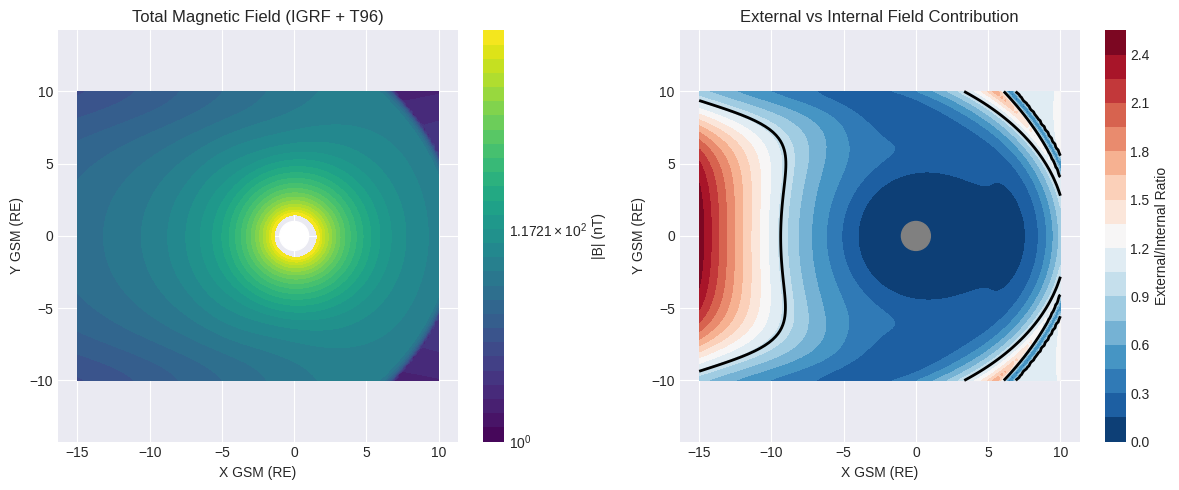

Black contour shows where external field equals internal field
Red regions: external field dominates (magnetosphere)
Blue regions: internal field dominates (near Earth)


In [22]:
# Example: Total field = IGRF (internal) + T96 (external)

# Grid in equatorial plane
nx = 100
x_eq = np.linspace(-15, 10, nx)
y_eq = np.linspace(-10, 10, nx)
X_eq, Y_eq = np.meshgrid(x_eq, y_eq)
Z_eq = np.zeros_like(X_eq)

# Flatten
x_flat = X_eq.ravel()
y_flat = Y_eq.ravel()
z_flat = Z_eq.ravel()

# Calculate internal field (IGRF)
bx_int, by_int, bz_int = geopack.igrf_gsm_vectorized(x_flat, y_flat, z_flat)

# Calculate external field (T96)
parmod = np.zeros(10)
parmod[0] = 2.0   # Pdyn = 2 nPa
parmod[1] = -20.0 # Dst = -20 nT
parmod[3] = -5.0  # BzIMF = -5 nT

bx_ext, by_ext, bz_ext = geopack.t96_vectorized(parmod, ps, x_flat, y_flat, z_flat)

# Total field
bx_total = bx_int + bx_ext
by_total = by_int + by_ext
bz_total = bz_int + bz_ext
b_magnitude = np.sqrt(bx_total**2 + by_total**2 + bz_total**2)

# Reshape and plot
B_mag = b_magnitude.reshape(X_eq.shape)

plt.figure(figsize=(12, 5))

# Total field
plt.subplot(1, 2, 1)
levels = np.logspace(0, 4, 30)
cs = plt.contourf(X_eq, Y_eq, B_mag, levels=levels, 
                  norm=matplotlib.colors.LogNorm(), cmap='viridis')
plt.colorbar(cs, label='|B| (nT)')
plt.xlabel('X GSM (RE)')
plt.ylabel('Y GSM (RE)')
plt.title('Total Magnetic Field (IGRF + T96)')

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
plt.gca().add_patch(earth)
plt.axis('equal')

# Ratio of external to internal
b_int_mag = np.sqrt(bx_int**2 + by_int**2 + bz_int**2).reshape(X_eq.shape)
b_ext_mag = np.sqrt(bx_ext**2 + by_ext**2 + bz_ext**2).reshape(X_eq.shape)
ratio = b_ext_mag / (b_int_mag + 1e-10)

plt.subplot(1, 2, 2)
cs2 = plt.contourf(X_eq, Y_eq, ratio, levels=20, cmap='RdBu_r')
plt.colorbar(cs2, label='External/Internal Ratio')
plt.contour(X_eq, Y_eq, ratio, levels=[1.0], colors='black', linewidths=2)
plt.xlabel('X GSM (RE)')
plt.ylabel('Y GSM (RE)')
plt.title('External vs Internal Field Contribution')

# Add Earth
earth2 = plt.Circle((0, 0), 1, color='gray', zorder=10)
plt.gca().add_patch(earth2)
plt.axis('equal')

plt.tight_layout()
plt.show()

print("Black contour shows where external field equals internal field")
print("Red regions: external field dominates (magnetosphere)")
print("Blue regions: internal field dominates (near Earth)")

## Summary and Best Practices

### Key Points:

1. **Always initialize with `recalc()`** before any IGRF calculations
2. **Use vectorized functions** for multiple points (even as few as 10)
3. **Accuracy is preserved** - identical results to scalar version
4. **Significant speedup** - 10-20x for typical use cases

### Performance Guidelines:

- **< 10 points**: Either version is fine
- **10-100 points**: 2-3x speedup with vectorized
- **100-1000 points**: 8-10x speedup
- **> 1000 points**: 10-20x speedup, processing >200k points/second

### Common Use Cases:

1. **Satellite orbit analysis**: Process entire orbit at once
2. **Global field maps**: Calculate on regular grids efficiently
3. **Field line tracing**: Start points for multiple field lines
4. **Model comparisons**: IGRF + external models for total field

### API Reference:

```python
# Spherical coordinates (r, theta, phi)
br, btheta, bphi = geopack.igrf_geo_vectorized(r, theta, phi)

# GSM coordinates
bx_gsm, by_gsm, bz_gsm = geopack.igrf_gsm_vectorized(x_gsm, y_gsm, z_gsm)

# GSW coordinates
bx_gsw, by_gsw, bz_gsw = geopack.igrf_gsw_vectorized(x_gsw, y_gsw, z_gsw)
```

All functions accept scalars or arrays and return matching types.